# Modelling Human Error Patterns in Air Traffic Control

### NASA ASRS Data Preparation and Analysis

This notebook contains the data preparation, exploratory analysis, sequence-model development and evaluation used for the dissertation project. The workflow begins with the original NASA ASRS exports and keeps the raw files unchanged so that all subsequent processing steps can be reproduced.

In [1]:
# Connecting to Google Drive so that datasets, figures and trained models
# remain available even if the Colab runtime is restarted.

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 1. Project Setup and Source Data

This analysis uses three original CSV exports obtained from the NASA Aviation
Safety Reporting System (ASRS) Database Online, covering 2009–2025. Data
acquisition was performed separately from the computational analysis and is
described in the accompanying dissertation.

The notebook expects the original exports to be available in the configured
raw-data directory. The source files are treated as read-only inputs and are
not modified by the analysis. Processed datasets, figures, tables and trained
models are saved separately.

In [2]:
from pathlib import Path

# Project location for the study
project_folder = Path('/content/drive/MyDrive/ATC_Dissertation')

# Input data location
raw_data_folder = project_folder / 'data' / 'raw'

# Output locations created by this notebook
processed_data_folder = project_folder / 'data' / 'processed'
figures_folder = project_folder / 'figures'
tables_folder = project_folder / 'tables'
models_folder = project_folder / 'models'
outputs_folder = project_folder / 'outputs'

# Create folders used for generated outputs
for folder in [
    processed_data_folder,
    figures_folder,
    tables_folder,
    models_folder,
    outputs_folder
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project paths configured.")
print(f"Source data folder: {raw_data_folder}")

Project paths configured.
Source data folder: /content/drive/MyDrive/ATC_Dissertation/data/raw


## 2. Source Data

The original NASA ASRS data were obtained separately through the ASRS Database
Online and stored as three CSV exports covering 2009–2025. The notebook does not
download or generate these source files.

For this implementation, the original exports are stored in the project's
`data/raw/` directory in Google Drive. The notebook verifies their presence before
beginning the analysis and keeps the original files unchanged.

In [3]:
# Original NASA ASRS exports used in the study
asrs_file_paths = {
    '2009-2013': raw_data_folder / 'ASRS_DBOnline_2009-2013.csv',
    '2014-2017': raw_data_folder / 'ASRS_DBOnline_2014-2017.csv',
    '2018-2025': raw_data_folder / 'ASRS_DBOnline_2018-2025.csv'
}

# Verify that all source files are available before continuing
missing_files = []

for period, file_path in asrs_file_paths.items():
    if file_path.exists():
        print(f"{period}: source file found")
    else:
        print(f"{period}: source file missing")
        missing_files.append(file_path)

if missing_files:
    raise FileNotFoundError(
        "One or more NASA ASRS source files are missing from the configured "
        "raw-data folder. Check the data location before continuing."
    )

2009-2013: source file found
2014-2017: source file found
2018-2025: source file found


### Reading the NASA ASRS Export Format

The ASRS CSV files contain two header rows. The first identifies broad sections such as Time, Environment, Person 1 and Report 1, while the second contains the individual field names. Both levels are retained when the files are read so that similarly named fields belonging to different sections are not confused.

The two header levels are then combined into clear Python-friendly column names. For example, the Human Factors fields for Person 1 and Person 2 remain separate.

In [4]:
import re
import pandas as pd


def make_readable_column_name(section, field):
    """Combine the two ASRS header levels into one clear column name."""

    section = str(section).strip()
    field = str(field).strip()

    # Some ASRS columns do not have a meaningful first-level heading.
    if section == '' or section.lower().startswith('unnamed'):
        combined_name = field
    else:
        combined_name = f'{section}_{field}'

    # Converting spaces and punctuation into underscores so that the
    # resulting names are easier to use throughout the analysis.
    readable_name = re.sub(
        r'[^A-Za-z0-9]+',
        '_',
        combined_name
    ).strip('_').lower()

    return readable_name


def read_asrs_file(file_path):
    """Reads one NASA ASRS export while preserving its two-level header."""

    asrs_data = pd.read_csv(
        file_path,
        header=[0, 1],
        skip_blank_lines=True,
        dtype=str,
        low_memory=False
    )

    readable_columns = [
        make_readable_column_name(section, field)
        for section, field in asrs_data.columns
    ]

    # Duplicate names would make  analysis in future ambiguous, so stopping here
    # rather than allowing that problem to pass unnoticed.
    if len(readable_columns) != len(set(readable_columns)):
        raise ValueError(
            f'Duplicate column names were created while reading {file_path.name}.'
        )

    asrs_data.columns = readable_columns

    return asrs_data

In [5]:
asrs_2009_2013 = read_asrs_file(asrs_file_paths['2009-2013'])
asrs_2014_2017 = read_asrs_file(asrs_file_paths['2014-2017'])
asrs_2018_2025 = read_asrs_file(asrs_file_paths['2018-2025'])

In [6]:
source_file_summary = pd.DataFrame({
    'Period': ['2009-2013', '2014-2017', '2018-2025'],
    'Number of reports': [
        len(asrs_2009_2013),
        len(asrs_2014_2017),
        len(asrs_2018_2025)
    ],
    'Number of columns': [
        asrs_2009_2013.shape[1],
        asrs_2014_2017.shape[1],
        asrs_2018_2025.shape[1]
    ]
})

display(source_file_summary)

,Period,Number of reports,Number of columns
0,2009-2013,3671,126
1,2014-2017,3045,126
2,2018-2025,3089,126


### Checking Dataset Compatibility

Before combining the exports, their column structures are compared. A matching schema is important because rows from different periods should represent the same variables after concatenation.

In [7]:
same_columns_2014_2017 = (
    asrs_2009_2013.columns.tolist()
    == asrs_2014_2017.columns.tolist()
)

same_columns_2018_2025 = (
    asrs_2009_2013.columns.tolist()
    == asrs_2018_2025.columns.tolist()
)

if same_columns_2014_2017 and same_columns_2018_2025:
    print("All three ASRS files have the same column structure.")
else:
    print("The file structures are different and should be inspected before merging.")

All three ASRS files have the same column structure.


## 3. Combining the ASRS Exports

After confirming that the three exports share the same structure, they are combined into one dataset. A source-period variable is added before merging so that the origin of every report remains traceable during later checks.

In [8]:
asrs_combined = pd.concat(
    [
        asrs_2009_2013.assign(source_period='2009-2013'),
        asrs_2014_2017.assign(source_period='2014-2017'),
        asrs_2018_2025.assign(source_period='2018-2025')
    ],
    ignore_index=True
)

print(f"Combined reports: {len(asrs_combined):,}")
print(f"Original ASRS variables: {asrs_2009_2013.shape[1]}")
print(f"Columns after adding source period: {asrs_combined.shape[1]}")

Combined reports: 9,805
Original ASRS variables: 126
Columns after adding source period: 127


## 4. Initial Dataset Audit

The combined dataset is checked before any records or variables are removed. This stage looks for duplicate report identifiers, unexpected dates and completely empty variables. Performing these checks before cleaning provides a transparent record of how the final analysis dataset is derived.

In [9]:
duplicate_acn_count = asrs_combined['acn'].duplicated().sum()

fully_empty_columns = [
    column
    for column in asrs_combined.columns
    if asrs_combined[column].isna().all()
]

print(f"Total reports: {len(asrs_combined):,}")
print(f"Unique ACNs: {asrs_combined['acn'].nunique():,}")
print(f"Duplicate ACNs: {duplicate_acn_count}")
print(f"Completely empty columns: {len(fully_empty_columns)}")

Total reports: 9,805
Unique ACNs: 9,805
Duplicate ACNs: 0
Completely empty columns: 29


In [10]:
asrs_audit = asrs_combined.copy()

# ASRS dates are mostly stored as YYYYMM.
# Extracting the first four digits gives us a consistent report year.
asrs_audit['report_year'] = pd.to_numeric(
    asrs_audit['time_date'].str.extract(r'(\d{4})')[0],
    errors='coerce'
)

year_summary = (
    asrs_audit['report_year']
    .value_counts()
    .sort_index()
    .rename_axis('Year')
    .reset_index(name='Number of reports')
)

display(year_summary)

,Year,Number of reports
0,2005,1
1,2009,426
2,2010,859
3,2011,946
4,2012,865
5,2013,574
6,2014,672
7,2015,736
8,2016,810
9,2017,827


In [11]:
outside_study_period = asrs_audit[
    ~asrs_audit['report_year'].between(2009, 2025)
]

display(
    outside_study_period[
        [
            'acn',
            'time_date',
            'place_locale_reference',
            'report_1_synopsis',
            'source_period'
        ]
    ]
)

,acn,time_date,place_locale_reference,report_1_synopsis,source_period
0,716228,2005,ZMA.ARTCC,CTLR RPTS FREQ OUTAGES IN ZMA AIRSPACE THAT HA...,2009-2013


In [12]:
merged_file_path = (
    processed_data_folder
    / 'asrs_merged_unfiltered.csv'
)

asrs_combined.to_csv(
    merged_file_path,
    index=False
)

print(f"Merged dataset saved to:\n{merged_file_path}")

Merged dataset saved to:
/content/drive/MyDrive/ATC_Dissertation/data/processed/asrs_merged_unfiltered.csv


## 5. Cleaning the Combined Dataset

The combined data are cleaned only after the three source files have been merged and checked. Records outside the predefined 2009–2025 study period are removed, completely empty variables are discarded, and duplicate report identifiers and narratives are checked before further analysis.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

analysis_data = asrs_combined.copy()

# Converting the ASRS date field into a year that can be checked consistently.
analysis_data['report_year'] = pd.to_numeric(
    analysis_data['time_date'].str.extract(r'(\d{4})')[0],
    errors='coerce'
)

reports_before_date_filter = len(analysis_data)

analysis_data = analysis_data[
    analysis_data['report_year'].between(2009, 2025)
].copy()

reports_removed_by_date = reports_before_date_filter - len(analysis_data)

# Columns containing no information at all are not useful for the later analysis.
completely_empty_columns = [
    column
    for column in analysis_data.columns
    if analysis_data[column].isna().all()
]

analysis_data.drop(
    columns=completely_empty_columns,
    inplace=True
)

print(f"Reports before date filtering: {reports_before_date_filter:,}")
print(f"Reports outside 2009–2025 removed: {reports_removed_by_date:,}")
print(f"Reports remaining: {len(analysis_data):,}")
print(f"Completely empty columns removed: {len(completely_empty_columns)}")
print(f"Columns remaining: {analysis_data.shape[1]}")

Reports before date filtering: 9,805
Reports outside 2009–2025 removed: 1
Reports remaining: 9,804
Completely empty columns removed: 29
Columns remaining: 99


### Duplicate Checks

ASRS accession numbers provide a useful report identifier. Exact duplicate narratives are also checked because repeated text could otherwise appear in more than one data split and artificially improve model performance.

In [14]:
duplicate_acn_count = analysis_data['acn'].duplicated().sum()

duplicate_narrative_count = (
    analysis_data['report_1_narrative']
    .duplicated()
    .sum()
)

print(f"Duplicate ACNs: {duplicate_acn_count}")
print(f"Exact duplicate Report 1 narratives: {duplicate_narrative_count}")

Duplicate ACNs: 0
Exact duplicate Report 1 narratives: 0


In [15]:
cleaned_dataset_path = (
    processed_data_folder
    / 'asrs_cleaned_2009_2025.csv'
)

analysis_data.to_csv(
    cleaned_dataset_path,
    index=False
)

print(f"Cleaned dataset saved to:\n{cleaned_dataset_path}")

Cleaned dataset saved to:
/content/drive/MyDrive/ATC_Dissertation/data/processed/asrs_cleaned_2009_2025.csv


## 6. Exploratory Data Analysis

Exploratory analysis is used to understand the coverage, reporting patterns, narrative characteristics and human-factor labels before the modelling dataset is created. The figures generated here are also saved separately so that suitable visualisations can later be selected for the dissertation report.

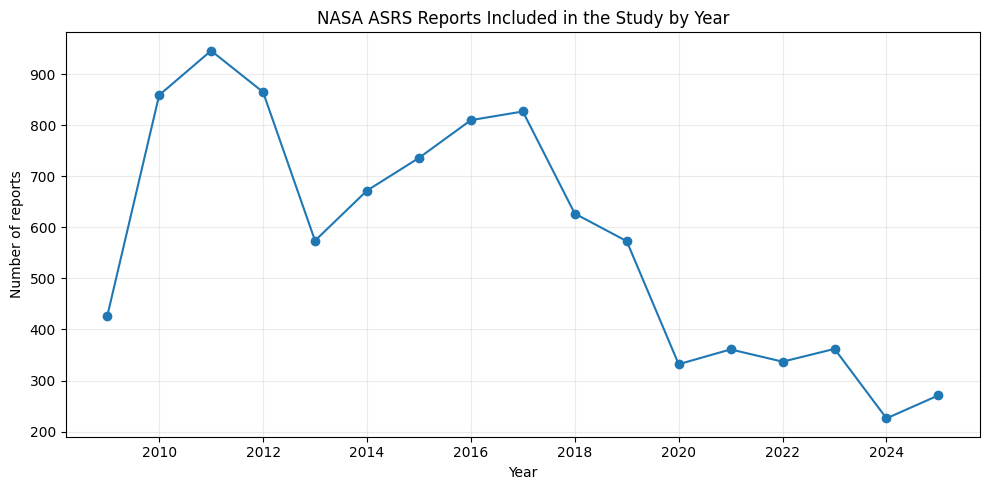

In [16]:
reports_by_year = (
    analysis_data['report_year']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    reports_by_year.index,
    reports_by_year.values,
    marker='o'
)

ax.set_title('NASA ASRS Reports Included in the Study by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of reports')
ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    figures_folder / 'reports_by_year.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Missing Information in Key Variables

Rather than examining missingness across every exported variable, this view focuses on fields that are most relevant to the research: narrative text, human-factor annotations, event information and selected operational context.

,Missing (%)
Report 1 Narrative,0.00
Person 1 Function,0.00
Event Anomaly,0.07
Primary Problem,0.16
Contributing Factors,0.23
Person 1 Human Factors,7.29
Report 2 Narrative,85.25
Person 2 Human Factors,89.65


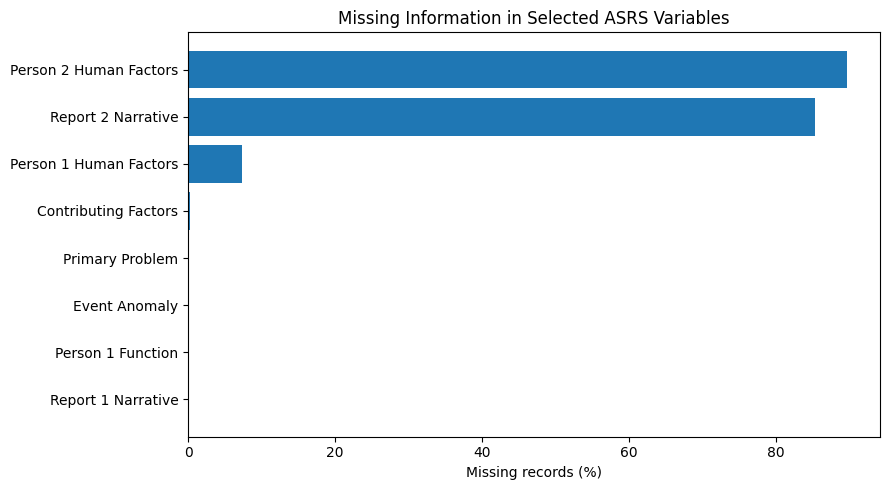

In [17]:
fields_for_missingness_check = {
    'Report 1 Narrative': 'report_1_narrative',
    'Report 2 Narrative': 'report_2_narrative',
    'Person 1 Human Factors': 'person_1_human_factors',
    'Person 2 Human Factors': 'person_2_human_factors',
    'Primary Problem': 'assessments_primary_problem',
    'Contributing Factors': 'assessments_contributing_factors_situations',
    'Event Anomaly': 'events_anomaly',
    'Person 1 Function': 'person_1_function'
}

missingness_summary = pd.Series({
    display_name: analysis_data[column_name].isna().mean() * 100
    for display_name, column_name
    in fields_for_missingness_check.items()
}).sort_values()

display(
    missingness_summary
    .rename('Missing (%)')
    .round(2)
    .to_frame()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    missingness_summary.index,
    missingness_summary.values
)

ax.set_title('Missing Information in Selected ASRS Variables')
ax.set_xlabel('Missing records (%)')

plt.tight_layout()

plt.savefig(
    figures_folder / 'selected_variable_missingness.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 7. Human-Factor Label Exploration

The Human Factors field can contain more than one annotation for the same report. Individual factors are therefore separated at the semicolon and analysed independently.

In [18]:
def separate_human_factor_labels(value):
    """Turns one semicolon-separated ASRS field into a clean list of labels."""

    if pd.isna(value):
        return []

    return [
        factor.strip()
        for factor in value.split(';')
        if factor.strip()
    ]


analysis_data['human_factor_list'] = (
    analysis_data['person_1_human_factors']
    .apply(separate_human_factor_labels)
)

human_factor_counts = (
    analysis_data['human_factor_list']
    .explode()
    .dropna()
    .value_counts()
)

human_factor_summary = (
    human_factor_counts
    .rename_axis('Human factor')
    .reset_index(name='Number of reports')
)

display(human_factor_summary)

,Human factor,Number of reports
0,Situational Awareness,5929
1,Communication Breakdown,4216
2,Confusion,3130
3,Distraction,2346
4,Workload,1982
5,Time Pressure,1067
6,Training / Qualification,1026
7,Human-Machine Interface,965
8,Other / Unknown,847
9,Troubleshooting,591


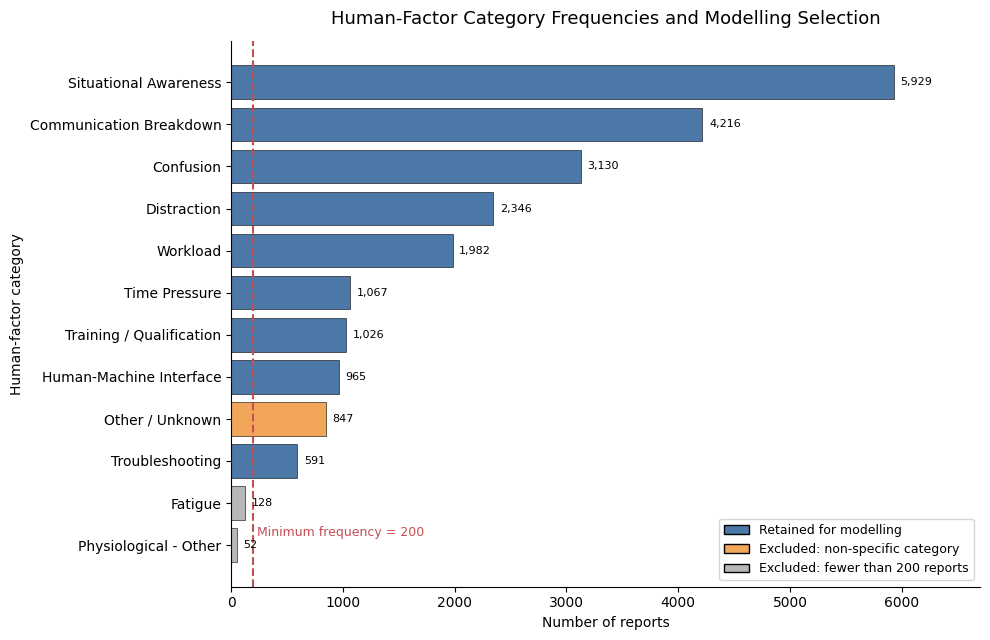

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Human-factors categories are retained for modelling
retained_categories = [
    'Situational Awareness',
    'Communication Breakdown',
    'Confusion',
    'Distraction',
    'Workload',
    'Time Pressure',
    'Training / Qualification',
    'Human-Machine Interface',
    'Troubleshooting'
]

# Sorting categories by frequency
plot_data = human_factor_counts.sort_values()

# Colour by selection status
bar_colours = []

for category in plot_data.index:
    if category in retained_categories:
        bar_colours.append('#4C78A8')
    elif category == 'Other / Unknown':
        bar_colours.append('#F2A65A')
    else:
        bar_colours.append('#B8B8B8')

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    plot_data.index,
    plot_data.values,
    color=bar_colours,
    edgecolor='black',
    linewidth=0.4
)

# Minimum-frequency threshold
ax.axvline(
    x=200,
    color='#C44E52',
    linestyle='--',
    linewidth=1.5
)

ax.text(
    230,
    0.15,
    'Minimum frequency = 200',
    color='#C44E52',
    fontsize=9,
    va='bottom'
)

# Display counts at the end of each bar
for bar, value in zip(bars, plot_data.values):
    ax.text(
        value + 60,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=8
    )

ax.set_title(
    'Human-Factor Category Frequencies and Modelling Selection',
    fontsize=13,
    pad=12
)

ax.set_xlabel('Number of reports')
ax.set_ylabel('Human-factor category')

legend_elements = [
    Patch(
        facecolor='#4C78A8',
        edgecolor='black',
        label='Retained for modelling'
    ),
    Patch(
        facecolor='#F2A65A',
        edgecolor='black',
        label='Excluded: non-specific category'
    ),
    Patch(
        facecolor='#B8B8B8',
        edgecolor='black',
        label='Excluded: fewer than 200 reports'
    )
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=9,
    frameon=True
)

# Leave enough room for frequency labels
ax.set_xlim(0, plot_data.max() * 1.13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Overwrites the original graph file
plt.savefig(
    figures_folder / 'human_factor_frequency.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Selecting Human-Factor Categories for Modelling

Very rare labels provide too few positive examples for reliable training and evaluation. The category "Other / Unknown" is also not treated as a specific human-factor pattern. For the main modelling experiment, meaningful categories occurring in at least 200 reports are retained.

The threshold is kept as a named parameter so that the decision is transparent and can be changed if required.

In [20]:
minimum_reports_per_label = 200

selected_human_factor_labels = [
    label
    for label, count in human_factor_counts.items()
    if (
        label != 'Other / Unknown'
        and count >= minimum_reports_per_label
    )
]

selected_label_summary = (
    human_factor_counts
    .loc[selected_human_factor_labels]
    .rename_axis('Human factor')
    .reset_index(name='Number of reports')
)

display(selected_label_summary)

print(
    f"\nNumber of human-factor categories selected: "
    f"{len(selected_human_factor_labels)}"
)

,Human factor,Number of reports
0,Situational Awareness,5929
1,Communication Breakdown,4216
2,Confusion,3130
3,Distraction,2346
4,Workload,1982
5,Time Pressure,1067
6,Training / Qualification,1026
7,Human-Machine Interface,965
8,Troubleshooting,591



Number of human-factor categories selected: 9


## 8. Preparing the Modelling Dataset

Report 1 Narrative is used as the textual input and Person 1 Human Factors provides the corresponding supervised labels. Reports are retained when they contain a narrative and at least one of the selected human-factor categories.

Only the selected labels are used as model targets.

In [21]:
modelling_data = analysis_data[
    [
        'acn',
        'report_year',
        'report_1_narrative',
        'person_1_human_factors'
    ]
].copy()

modelling_data.rename(
    columns={
        'report_1_narrative': 'narrative',
        'person_1_human_factors': 'original_human_factors'
    },
    inplace=True
)

modelling_data['human_factor_list'] = (
    modelling_data['original_human_factors']
    .apply(separate_human_factor_labels)
)

modelling_data['selected_human_factors'] = (
    modelling_data['human_factor_list']
    .apply(
        lambda factors: [
            factor
            for factor in factors
            if factor in selected_human_factor_labels
        ]
    )
)

modelling_data = modelling_data[
    modelling_data['narrative'].notna()
    & modelling_data['narrative'].str.strip().ne('')
    & modelling_data['selected_human_factors'].str.len().gt(0)
].copy()

modelling_data.reset_index(
    drop=True,
    inplace=True
)

print(f"Reports available before modelling selection: {len(analysis_data):,}")
print(f"Reports retained for modelling: {len(modelling_data):,}")

Reports available before modelling selection: 9,804
Reports retained for modelling: 8,437


In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

label_encoder = MultiLabelBinarizer(
    classes=selected_human_factor_labels
)

target_matrix = label_encoder.fit_transform(
    modelling_data['selected_human_factors']
).astype(np.int32)

human_factor_labels = list(label_encoder.classes_)

print(f"Target matrix shape: {target_matrix.shape}")
print("\nModelled human-factor categories:")

for label in human_factor_labels:
    print(f"- {label}")

Target matrix shape: (8437, 9)

Modelled human-factor categories:
- Situational Awareness
- Communication Breakdown
- Confusion
- Distraction
- Workload
- Time Pressure
- Training / Qualification
- Human-Machine Interface
- Troubleshooting


In [23]:
def make_safe_label_name(label):
    return (
        label.lower()
        .replace(' / ', '_')
        .replace('/', '_')
        .replace(' ', '_')
        .replace('-', '_')
    )


for column_number, label in enumerate(human_factor_labels):
    target_column_name = (
        'target_'
        + make_safe_label_name(label)
    )

    modelling_data[target_column_name] = (
        target_matrix[:, column_number]
    )


modelling_dataset_path = (
    processed_data_folder
    / 'asrs_modelling_dataset.csv'
)

modelling_data.to_csv(
    modelling_dataset_path,
    index=False
)

print(f"Modelling dataset saved to:\n{modelling_dataset_path}")

Modelling dataset saved to:
/content/drive/MyDrive/ATC_Dissertation/data/processed/asrs_modelling_dataset.csv


### Narrative Length

Narrative length is examined before choosing the sequence length used by the neural networks. Using a data-informed sequence length avoids selecting an arbitrary padding value while also preventing a small number of unusually long narratives from making every training sequence unnecessarily large.

In [24]:
modelling_data['narrative_word_count'] = (
    modelling_data['narrative']
    .str.split()
    .str.len()
)

narrative_length_summary = (
    modelling_data['narrative_word_count']
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(
    narrative_length_summary
    .round(1)
    .to_frame('Word count')
)

,Word count
count,8437.0
mean,304.9
std,195.5
min,10.0
50%,261.0
75%,385.0
90%,544.0
95%,668.2
99%,982.0
max,2145.0


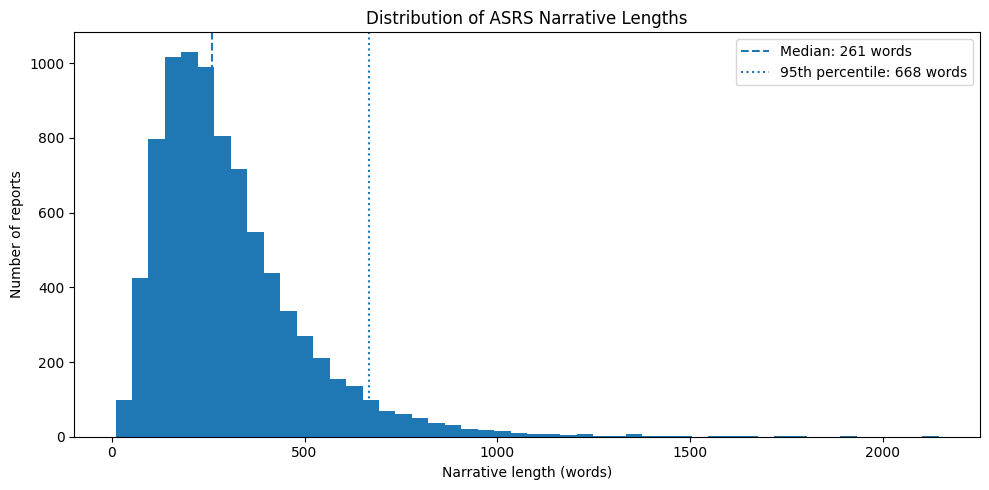

In [25]:
median_narrative_length = (
    modelling_data['narrative_word_count']
    .median()
)

ninety_fifth_percentile_length = (
    modelling_data['narrative_word_count']
    .quantile(0.95)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    modelling_data['narrative_word_count'],
    bins=50
)

ax.axvline(
    median_narrative_length,
    linestyle='--',
    label=f'Median: {median_narrative_length:.0f} words'
)

ax.axvline(
    ninety_fifth_percentile_length,
    linestyle=':',
    label=(
        f'95th percentile: '
        f'{ninety_fifth_percentile_length:.0f} words'
    )
)

ax.set_title('Distribution of ASRS Narrative Lengths')
ax.set_xlabel('Narrative length (words)')
ax.set_ylabel('Number of reports')
ax.legend()

plt.tight_layout()

plt.savefig(
    figures_folder / 'narrative_length_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

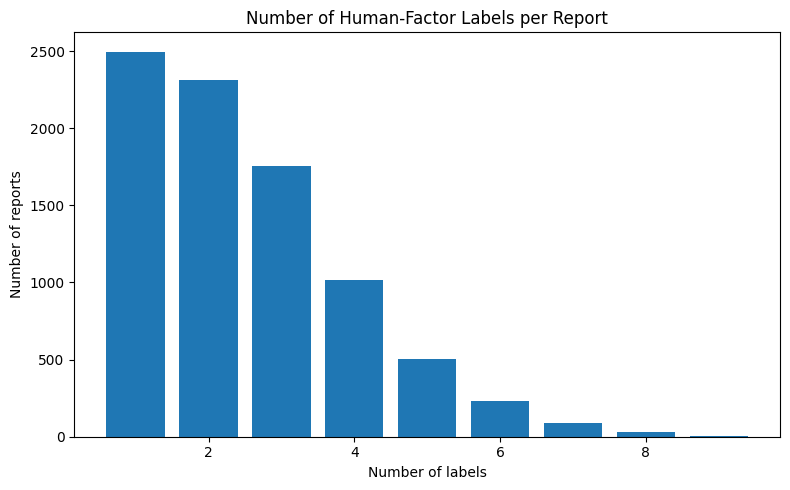

In [26]:
modelling_data['number_of_selected_labels'] = (
    target_matrix.sum(axis=1)
)

label_count_distribution = (
    modelling_data['number_of_selected_labels']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    label_count_distribution.index,
    label_count_distribution.values
)

ax.set_title('Number of Human-Factor Labels per Report')
ax.set_xlabel('Number of labels')
ax.set_ylabel('Number of reports')

plt.tight_layout()

plt.savefig(
    figures_folder / 'labels_per_report.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

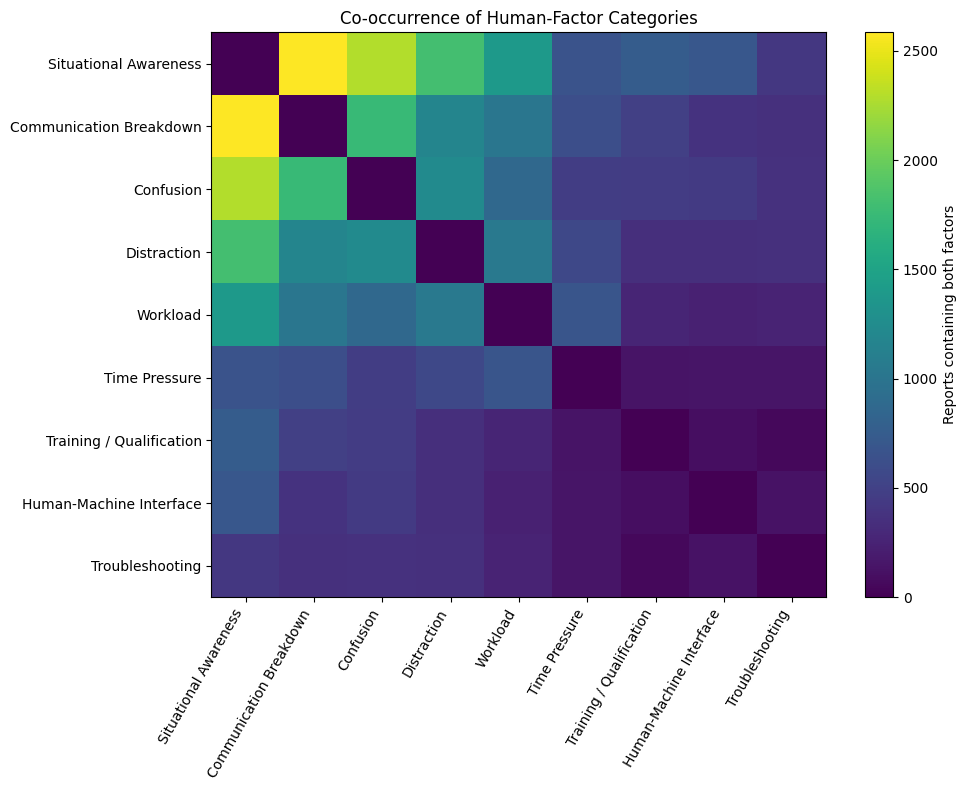

In [27]:
human_factor_cooccurrence = (
    target_matrix.T @ target_matrix
)

# The diagonal only shows the total frequency of each label.
# Setting it to zero makes relationships between different labels easier to see.
np.fill_diagonal(
    human_factor_cooccurrence,
    0
)

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    human_factor_cooccurrence,
    aspect='auto'
)

ax.set_xticks(
    range(len(human_factor_labels)),
    human_factor_labels,
    rotation=60,
    ha='right'
)

ax.set_yticks(
    range(len(human_factor_labels)),
    human_factor_labels
)

ax.set_title('Co-occurrence of Human-Factor Categories')

fig.colorbar(
    image,
    ax=ax,
    label='Reports containing both factors'
)

plt.tight_layout()

plt.savefig(
    figures_folder / 'human_factor_cooccurrence.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 9. Train, Validation and Test Split

The modelling data are divided into 70% training, 15% validation and 15% testing sets. Multi-label stratification is used so that the prevalence of each human-factor category remains as consistent as possible across all three subsets.

Threshold selection and automated model selection are performed using the validation data. The test set is used to report the final performance of the implemented models.

In [28]:
%pip install -q iterative-stratification

In [29]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

random_seed = 2026

narratives = (
    modelling_data['narrative']
    .astype(str)
    .to_numpy()
)

report_acns = (
    modelling_data['acn']
    .astype(str)
    .to_numpy()
)

# First separates 70% training data from the remaining 30%.
train_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=random_seed
)

train_indices, temporary_indices = next(
    train_splitter.split(
        np.zeros((len(narratives), 1)),
        target_matrix
    )
)

# Splits the remaining 30% equally into validation and test sets.
validation_test_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=random_seed
)

validation_relative_indices, test_relative_indices = next(
    validation_test_splitter.split(
        np.zeros((len(temporary_indices), 1)),
        target_matrix[temporary_indices]
    )
)

validation_indices = temporary_indices[
    validation_relative_indices
]

test_indices = temporary_indices[
    test_relative_indices
]

X_train = narratives[train_indices]
X_validation = narratives[validation_indices]
X_test = narratives[test_indices]

y_train = target_matrix[train_indices]
y_validation = target_matrix[validation_indices]
y_test = target_matrix[test_indices]

print(f"Training reports:   {len(X_train):,}")
print(f"Validation reports: {len(X_validation):,}")
print(f"Test reports:       {len(X_test):,}")

Training reports:   5,929
Validation reports: 1,254
Test reports:       1,254


In [30]:
split_label_distribution = pd.DataFrame({
    'Human factor': human_factor_labels,
    'Full dataset (%)': target_matrix.mean(axis=0) * 100,
    'Training (%)': y_train.mean(axis=0) * 100,
    'Validation (%)': y_validation.mean(axis=0) * 100,
    'Test (%)': y_test.mean(axis=0) * 100
})

display(
    split_label_distribution.round(2)
)

split_label_distribution.to_csv(
    tables_folder / 'label_distribution_across_splits.csv',
    index=False
)

,Human factor,Full dataset (%),Training (%),Validation (%),Test (%)
0,Situational Awareness,70.27,69.99,70.97,70.89
1,Communication Breakdown,49.97,49.77,50.48,50.40
2,Confusion,37.10,36.95,37.48,37.40
3,Distraction,27.81,27.69,28.07,28.07
4,Workload,23.49,23.39,23.76,23.68
5,Time Pressure,12.65,12.60,12.76,12.76
6,Training / Qualification,12.16,12.11,12.28,12.28
7,Human-Machine Interface,11.44,11.38,11.56,11.56
8,Troubleshooting,7.00,6.98,7.10,7.02


In [31]:
from sklearn.metrics import (
    accuracy_score,
    hamming_loss,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support
)


def choose_label_thresholds(
    true_labels,
    predicted_probabilities,
    label_names
):
    """Chooses an F1-optimised decision threshold separately for each label."""

    candidate_thresholds = np.arange(
        0.10,
        0.81,
        0.02
    )

    selected_thresholds = []
    threshold_results = []

    for label_index, label_name in enumerate(label_names):

        true_label = true_labels[
            :,
            label_index
        ]

        label_probabilities = predicted_probabilities[
            :,
            label_index
        ]

        best_threshold = 0.50
        best_f1 = -1

        for threshold in candidate_thresholds:

            predicted_label = (
                label_probabilities >= threshold
            ).astype(int)

            current_f1 = f1_score(
                true_label,
                predicted_label,
                zero_division=0
            )

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_threshold = threshold

        selected_thresholds.append(
            best_threshold
        )

        threshold_results.append({
            'Human factor': label_name,
            'Selected threshold': best_threshold,
            'Validation F1': best_f1
        })

    return (
        np.array(selected_thresholds),
        pd.DataFrame(threshold_results)
    )


def evaluate_multilabel_predictions(
    true_labels,
    predicted_probabilities,
    thresholds,
    model_name
):
    """Calculate multi-label classification metrics."""

    predicted_labels = (
        predicted_probabilities >= thresholds
    ).astype(int)

    results = {
        'Model': model_name,

        'Subset Accuracy': accuracy_score(
            true_labels,
            predicted_labels
        ),

        'Hamming Loss': hamming_loss(
            true_labels,
            predicted_labels
        ),

        'Micro Precision': precision_score(
            true_labels,
            predicted_labels,
            average='micro',
            zero_division=0
        ),

        'Micro Recall': recall_score(
            true_labels,
            predicted_labels,
            average='micro',
            zero_division=0
        ),

        'Micro F1': f1_score(
            true_labels,
            predicted_labels,
            average='micro',
            zero_division=0
        ),

        'Macro F1': f1_score(
            true_labels,
            predicted_labels,
            average='macro',
            zero_division=0
        ),

        'Weighted F1': f1_score(
            true_labels,
            predicted_labels,
            average='weighted',
            zero_division=0
        ),

        'Macro ROC-AUC': roc_auc_score(
            true_labels,
            predicted_probabilities,
            average='macro'
        ),

        'Macro Average Precision': average_precision_score(
            true_labels,
            predicted_probabilities,
            average='macro'
        )
    }

    return results, predicted_labels

## 10. Conventional NLP Baseline

A TF-IDF representation with one-vs-rest logistic regression is used as a conventional baseline. The baseline provides a reference point for judging whether the additional complexity of sequence-based neural networks produces a meaningful improvement.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
import joblib

tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train
)

X_validation_tfidf = tfidf_vectorizer.transform(
    X_validation
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

baseline_classifier = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ),
    n_jobs=-1
)

baseline_classifier.fit(
    X_train_tfidf,
    y_train
)

print("Baseline model training complete.")

Baseline model training complete.


In [33]:
baseline_validation_probabilities = (
    baseline_classifier.predict_proba(
        X_validation_tfidf
    )
)

baseline_thresholds, baseline_threshold_table = (
    choose_label_thresholds(
        y_validation,
        baseline_validation_probabilities,
        human_factor_labels
    )
)

print('Baseline thresholds selected from validation data:')
display(
    baseline_threshold_table.round(3)
)


baseline_test_probabilities = (
    baseline_classifier.predict_proba(
        X_test_tfidf
    )
)

baseline_metrics, baseline_test_predictions = (
    evaluate_multilabel_predictions(
        y_test,
        baseline_test_probabilities,
        baseline_thresholds,
        'TF-IDF + Logistic Regression'
    )
)

display(
    pd.DataFrame(
        [baseline_metrics]
    ).round(4)
)

Baseline thresholds selected from validation data:


,Human factor,Selected threshold,Validation F1
0,Situational Awareness,0.28,0.833
1,Communication Breakdown,0.40,0.728
2,Confusion,0.38,0.583
3,Distraction,0.40,0.520
4,Workload,0.50,0.587
5,Time Pressure,0.48,0.402
6,Training / Qualification,0.46,0.481
7,Human-Machine Interface,0.56,0.363
8,Troubleshooting,0.38,0.286


,Model,Subset Accuracy,Hamming Loss,Micro Precision,Micro Recall,Micro F1,Macro F1,Weighted F1,Macro ROC-AUC,Macro Average Precision
0,TF-IDF + Logistic Regression,0.0622,0.2727,0.5107,0.8104,0.6265,0.52,0.6379,0.7552,0.5204


## 11. Text Vectorisation for the Sequence Models

The vocabulary is learned only from the training narratives. Text is converted into integer token sequences while retaining common grammatical words rather than applying aggressive stop-word removal. The sequence length is based on the training-data narrative distribution and is rounded to a practical value.

In [34]:
import random
import tensorflow as tf

random.seed(random_seed)
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

print("TensorFlow version:", tf.__version__)
print(
    "GPU available:",
    len(tf.config.list_physical_devices('GPU')) > 0
)

TensorFlow version: 2.20.0
GPU available: True


In [35]:
training_word_counts = np.array([
    len(text.split())
    for text in X_train
])

training_95th_percentile = np.percentile(
    training_word_counts,
    95
)

# Round upward to the nearest 50 words.
sequence_length = int(
    np.ceil(
        training_95th_percentile / 50
    ) * 50
)

# These limits prevent an unusually short or long corpus
# from producing an impractical sequence size.
sequence_length = max(
    200,
    min(sequence_length, 800)
)

maximum_vocabulary_size = 12000

print(
    f"95th percentile narrative length: "
    f"{training_95th_percentile:.0f} words"
)

print(
    f"Sequence length used by the models: "
    f"{sequence_length} tokens"
)

95th percentile narrative length: 673 words
Sequence length used by the models: 700 tokens


In [36]:
text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=maximum_vocabulary_size,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int',
    output_sequence_length=sequence_length
)

training_text_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .batch(128)
)

text_vectorizer.adapt(
    training_text_dataset
)

vocabulary = text_vectorizer.get_vocabulary()

print(
    f"Vocabulary size learned from training data: "
    f"{len(vocabulary):,}"
)

Vocabulary size learned from training data: 12,000


In [37]:
X_train_sequences = (
    text_vectorizer(
        tf.constant(X_train)
    )
    .numpy()
)

X_validation_sequences = (
    text_vectorizer(
        tf.constant(X_validation)
    )
    .numpy()
)

X_test_sequences = (
    text_vectorizer(
        tf.constant(X_test)
    )
    .numpy()
)

print(
    "Training sequence matrix:",
    X_train_sequences.shape
)

Training sequence matrix: (5929, 700)


In [38]:
# Each human-factor category has a different frequency.
# These weights give positive and negative examples a more balanced
# influence on the loss for each individual label.

positive_counts = y_train.sum(axis=0)
negative_counts = len(y_train) - positive_counts

positive_label_weights = (
    len(y_train) / (2 * positive_counts)
)

negative_label_weights = (
    len(y_train) / (2 * negative_counts)
)

label_weight_summary = pd.DataFrame({
    'Human factor': human_factor_labels,
    'Positive examples': positive_counts,
    'Negative examples': negative_counts,
    'Positive weight': positive_label_weights,
    'Negative weight': negative_label_weights
})

display(
    label_weight_summary.round(3)
)

,Human factor,Positive examples,Negative examples,Positive weight,Negative weight
0,Situational Awareness,4150,1779,0.714,1.666
1,Communication Breakdown,2951,2978,1.005,0.995
2,Confusion,2191,3738,1.353,0.793
3,Distraction,1642,4287,1.805,0.692
4,Workload,1387,4542,2.137,0.653
5,Time Pressure,747,5182,3.969,0.572
6,Training / Qualification,718,5211,4.129,0.569
7,Human-Machine Interface,675,5254,4.392,0.564
8,Troubleshooting,414,5515,7.161,0.538


In [39]:
positive_weights_tensor = tf.constant(
    positive_label_weights,
    dtype=tf.float32
)

negative_weights_tensor = tf.constant(
    negative_label_weights,
    dtype=tf.float32
)


def balanced_multilabel_loss(y_true, y_pred):
    """Balanced binary cross-entropy calculated separately for each label."""

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    positive_loss = (
        positive_weights_tensor
        * y_true
        * tf.math.log(y_pred)
    )

    negative_loss = (
        negative_weights_tensor
        * (1 - y_true)
        * tf.math.log(1 - y_pred)
    )

    label_losses = -(
        positive_loss
        + negative_loss
    )

    return tf.reduce_mean(
        label_losses,
        axis=-1
    )

## 12. LSTM Model

The first sequence model uses an embedding layer followed by an LSTM. Dropout is included to reduce overfitting, while the final sigmoid layer produces an independent probability for each human-factor category.

In [40]:
number_of_labels = len(human_factor_labels)

embedding_dimension = 64

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(sequence_length,),
        dtype=tf.int64
    ),

    tf.keras.layers.Embedding(
        input_dim=len(vocabulary),
        output_dim=embedding_dimension,
        mask_zero=True
    ),

    tf.keras.layers.SpatialDropout1D(
        0.30
    ),

    tf.keras.layers.LSTM(
        64,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),

    tf.keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),

    tf.keras.layers.Dropout(
        0.40
    ),

    tf.keras.layers.Dense(
        number_of_labels,
        activation='sigmoid'
    )
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss=balanced_multilabel_loss,

    metrics=[
        tf.keras.metrics.AUC(
            curve='PR',
            multi_label=True,
            num_labels=number_of_labels,
            name='pr_auc'
        )
    ]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 700, 64)        │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 700, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,769 (3.07 MB)

 Trainable params: 805,769 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
lstm_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc',
        mode='max',
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        models_folder / 'lstm_best_model.keras',
        monitor='val_pr_auc',
        mode='max',
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_pr_auc',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=0.00001
    )
]

lstm_history = lstm_model.fit(
    X_train_sequences,
    y_train,

    validation_data=(
        X_validation_sequences,
        y_validation
    ),

    epochs=15,
    batch_size=64,

    callbacks=lstm_callbacks,
    verbose=1
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.7054 - pr_auc: 0.2802 - val_loss: 0.7041 - val_pr_auc: 0.2898 - learning_rate: 5.0000e-04
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.6994 - pr_auc: 0.2932 - val_loss: 0.7003 - val_pr_auc: 0.2908 - learning_rate: 5.0000e-04
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.6951 - pr_auc: 0.3075 - val_loss: 0.6970 - val_pr_auc: 0.3152 - learning_rate: 5.0000e-04
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.6789 - pr_auc: 0.3319 - val_loss: 0.6875 - val_pr_auc: 0.3372 - learning_rate: 5.0000e-04
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.6477 - pr_auc: 0.3908 - val_loss: 0.6920 - val_pr_auc: 0.3427 - learning_rate: 5.0000e-04
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.6092 - pr_auc: 0.4661 - val_loss: 0.7074 - val_pr_auc: 0.3518 - learning_rate: 5.0000e-04
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.5731 - pr_auc: 0.5244 - val_loss

## 13. Bidirectional GRU Model

The second sequence model uses a GRU within a bidirectional wrapper, allowing the completed narrative sequence to be processed in both directions. Its performance is compared with the unidirectional LSTM as an alternative recurrent sequence architecture. Because the models also differ in directionality, performance differences are interpreted as differences between the implemented architectures rather than being attributed solely to the LSTM and GRU gating mechanisms.

In [42]:
bigru_model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(sequence_length,),
        dtype=tf.int64
    ),

    tf.keras.layers.Embedding(
        input_dim=len(vocabulary),
        output_dim=embedding_dimension,
        mask_zero=True
    ),

    tf.keras.layers.SpatialDropout1D(
        0.30
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            64,
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        )
    ),

    tf.keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),

    tf.keras.layers.Dropout(
        0.40
    ),

    tf.keras.layers.Dense(
        number_of_labels,
        activation='sigmoid'
    )
])

bigru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss=balanced_multilabel_loss,

    metrics=[
        tf.keras.metrics.AUC(
            curve='PR',
            multi_label=True,
            num_labels=number_of_labels,
            name='pr_auc'
        )
    ]
)

bigru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 700, 64)        │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 700, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,761 (3.15 MB)

 Trainable params: 826,761 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
bigru_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc',
        mode='max',
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        models_folder / 'bigru_best_model.keras',
        monitor='val_pr_auc',
        mode='max',
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_pr_auc',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=0.00001
    )
]

bigru_history = bigru_model.fit(
    X_train_sequences,
    y_train,

    validation_data=(
        X_validation_sequences,
        y_validation
    ),

    epochs=15,
    batch_size=64,

    callbacks=bigru_callbacks,
    verbose=1
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.7147 - pr_auc: 0.2836 - val_loss: 0.7112 - val_pr_auc: 0.3041 - learning_rate: 5.0000e-04
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.7050 - pr_auc: 0.3020 - val_loss: 0.7041 - val_pr_auc: 0.3174 - learning_rate: 5.0000e-04
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.6958 - pr_auc: 0.3273 - val_loss: 0.6917 - val_pr_auc: 0.3365 - learning_rate: 5.0000e-04
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.6703 - pr_auc: 0.3647 - val_loss: 0.6801 - val_pr_auc: 0.3606 - learning_rate: 5.0000e-04
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.6258 - pr_auc: 0.4273 - val_loss: 0.6940 - val_pr_auc: 0.3650 - learning_rate: 5.0000e-04
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.5869 - pr_auc: 0.4877 - val_loss: 0.7431 - val_pr_auc: 0.3545 - learning_rate: 5.0000e-04
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.5552 - pr_auc: 0.5339 - val_loss:

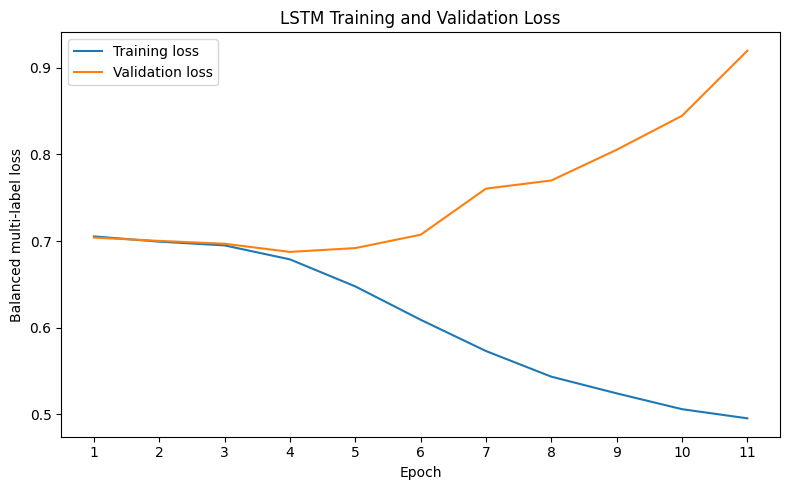

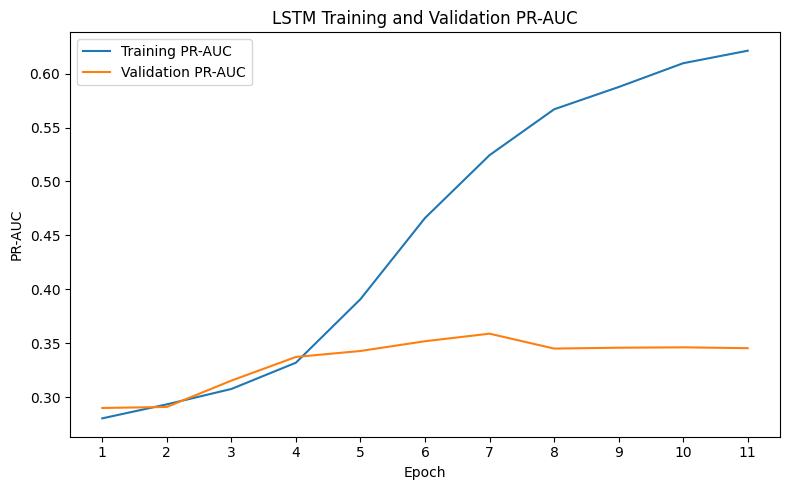

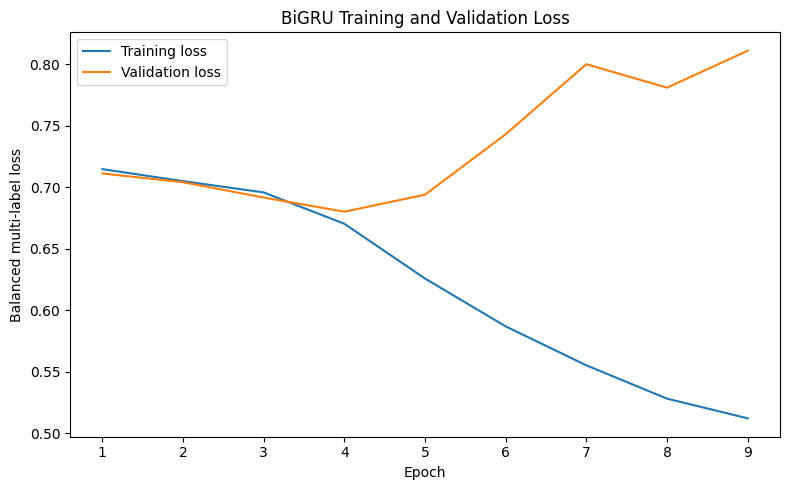

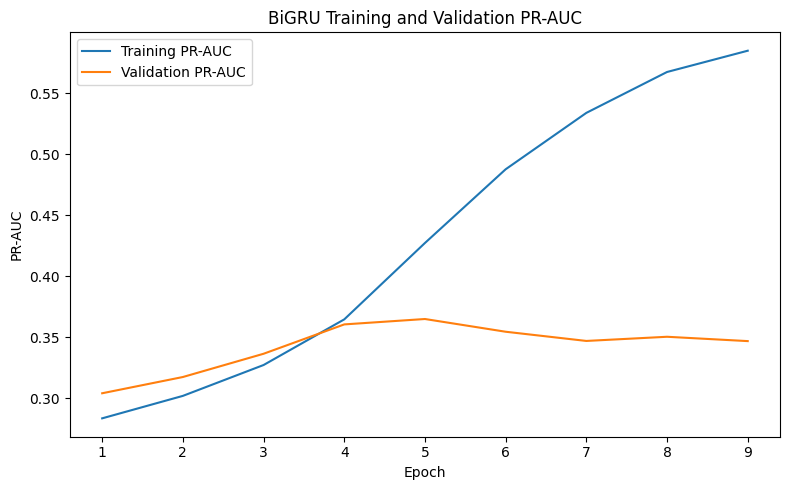

In [44]:
def save_training_curves(
    history,
    model_name,
    file_prefix
):
    """Save loss and PR-AUC curves as separate report-ready figures."""

    history_data = history.history


    epochs = np.arange(1, len(history_data['loss']) + 1)


    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        epochs,
        history_data['loss'],
        label='Training loss'
    )

    ax.plot(
        epochs,
        history_data['val_loss'],
        label='Validation loss'
    )

    ax.set_title(
        f'{model_name} Training and Validation Loss'
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Balanced multi-label loss')
    ax.set_xticks(epochs)
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        figures_folder / f'{file_prefix}_loss_curve.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()



    # PR-AUC curve
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        epochs,
        history_data['pr_auc'],
        label='Training PR-AUC'
    )

    ax.plot(
        epochs,
        history_data['val_pr_auc'],
        label='Validation PR-AUC'
    )

    ax.set_title(
        f'{model_name} Training and Validation PR-AUC'
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('PR-AUC')
    ax.set_xticks(epochs)
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        figures_folder / f'{file_prefix}_pr_auc_curve.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


save_training_curves(
    lstm_history,
    'LSTM',
    'lstm'
)

save_training_curves(
    bigru_history,
    'BiGRU',
    'bigru'
)

In [45]:
lstm_validation_probabilities = lstm_model.predict(
    X_validation_sequences,
    verbose=0
)

lstm_thresholds, lstm_threshold_table = (
    choose_label_thresholds(
        y_validation,
        lstm_validation_probabilities,
        human_factor_labels
    )
)

print('LSTM thresholds selected from validation data:')
display(
    lstm_threshold_table.round(3)
)


lstm_test_probabilities = lstm_model.predict(
    X_test_sequences,
    verbose=0
)

lstm_metrics, lstm_test_predictions = (
    evaluate_multilabel_predictions(
        y_test,
        lstm_test_probabilities,
        lstm_thresholds,
        'LSTM'
    )
)

display(
    pd.DataFrame(
        [lstm_metrics]
    ).round(4)
)

LSTM thresholds selected from validation data:


,Human factor,Selected threshold,Validation F1
0,Situational Awareness,0.10,0.830
1,Communication Breakdown,0.12,0.672
2,Confusion,0.10,0.545
3,Distraction,0.28,0.462
4,Workload,0.36,0.465
5,Time Pressure,0.38,0.271
6,Training / Qualification,0.46,0.265
7,Human-Machine Interface,0.54,0.281
8,Troubleshooting,0.20,0.231


,Model,Subset Accuracy,Hamming Loss,Micro Precision,Micro Recall,Micro F1,Macro F1,Weighted F1,Macro ROC-AUC,Macro Average Precision
0,LSTM,0.0167,0.4049,0.3982,0.85,0.5424,0.4328,0.5772,0.6041,0.3602


In [46]:
bigru_validation_probabilities = bigru_model.predict(
    X_validation_sequences,
    verbose=0
)

bigru_thresholds, bigru_threshold_table = (
    choose_label_thresholds(
        y_validation,
        bigru_validation_probabilities,
        human_factor_labels
    )
)

print('BiGRU thresholds selected from validation data:')
display(
    bigru_threshold_table.round(3)
)


bigru_test_probabilities = bigru_model.predict(
    X_test_sequences,
    verbose=0
)

bigru_metrics, bigru_test_predictions = (
    evaluate_multilabel_predictions(
        y_test,
        bigru_test_probabilities,
        bigru_thresholds,
        'BiGRU'
    )
)

display(
    pd.DataFrame(
        [bigru_metrics]
    ).round(4)
)

BiGRU thresholds selected from validation data:


,Human factor,Selected threshold,Validation F1
0,Situational Awareness,0.28,0.831
1,Communication Breakdown,0.40,0.671
2,Confusion,0.30,0.547
3,Distraction,0.38,0.474
4,Workload,0.42,0.435
5,Time Pressure,0.38,0.272
6,Training / Qualification,0.76,0.375
7,Human-Machine Interface,0.42,0.239
8,Troubleshooting,0.50,0.231


,Model,Subset Accuracy,Hamming Loss,Micro Precision,Micro Recall,Micro F1,Macro F1,Weighted F1,Macro ROC-AUC,Macro Average Precision
0,BiGRU,0.0191,0.4215,0.3895,0.8688,0.5378,0.438,0.5793,0.6181,0.3608


In [47]:
model_comparison = pd.DataFrame([
    baseline_metrics,
    lstm_metrics,
    bigru_metrics
])

display(
    model_comparison.round(4)
)

model_comparison.to_csv(
    tables_folder / 'model_performance_comparison.csv',
    index=False
)

,Model,Subset Accuracy,Hamming Loss,Micro Precision,Micro Recall,Micro F1,Macro F1,Weighted F1,Macro ROC-AUC,Macro Average Precision
0,TF-IDF + Logistic Regression,0.0622,0.2727,0.5107,0.8104,0.6265,0.5200,0.6379,0.7552,0.5204
1,LSTM,0.0167,0.4049,0.3982,0.8500,0.5424,0.4328,0.5772,0.6041,0.3602
2,BiGRU,0.0191,0.4215,0.3895,0.8688,0.5378,0.4380,0.5793,0.6181,0.3608


In [48]:
def create_per_label_results(
    true_labels,
    predicted_labels,
    label_names,
    model_name
):
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average=None,
            zero_division=0
        )
    )

    return pd.DataFrame({
        'Human factor': label_names,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Support': support,
        'Model': model_name
    })


lstm_label_results = create_per_label_results(
    y_test,
    lstm_test_predictions,
    human_factor_labels,
    'LSTM'
)

bigru_label_results = create_per_label_results(
    y_test,
    bigru_test_predictions,
    human_factor_labels,
    'BiGRU'
)

display(
    lstm_label_results.round(3)
)

display(
    bigru_label_results.round(3)
)

,Human factor,Precision,Recall,F1-score,Support,Model
0,Situational Awareness,0.709,1.000,0.830,889,LSTM
1,Communication Breakdown,0.504,0.998,0.670,632,LSTM
2,Confusion,0.374,1.000,0.544,469,LSTM
3,Distraction,0.298,0.795,0.434,352,LSTM
4,Workload,0.356,0.593,0.444,297,LSTM
5,Time Pressure,0.162,0.550,0.251,160,LSTM
6,Training / Qualification,0.167,0.571,0.259,154,LSTM
7,Human-Machine Interface,0.255,0.359,0.298,145,LSTM
8,Troubleshooting,0.104,0.398,0.165,88,LSTM


,Human factor,Precision,Recall,F1-score,Support,Model
0,Situational Awareness,0.710,0.998,0.829,889,BiGRU
1,Communication Breakdown,0.504,0.997,0.670,632,BiGRU
2,Confusion,0.378,0.998,0.548,469,BiGRU
3,Distraction,0.324,0.761,0.455,352,BiGRU
4,Workload,0.298,0.724,0.422,297,BiGRU
5,Time Pressure,0.153,0.769,0.255,160,BiGRU
6,Training / Qualification,0.331,0.279,0.303,154,BiGRU
7,Human-Machine Interface,0.159,0.669,0.257,145,BiGRU
8,Troubleshooting,0.134,0.420,0.203,88,BiGRU


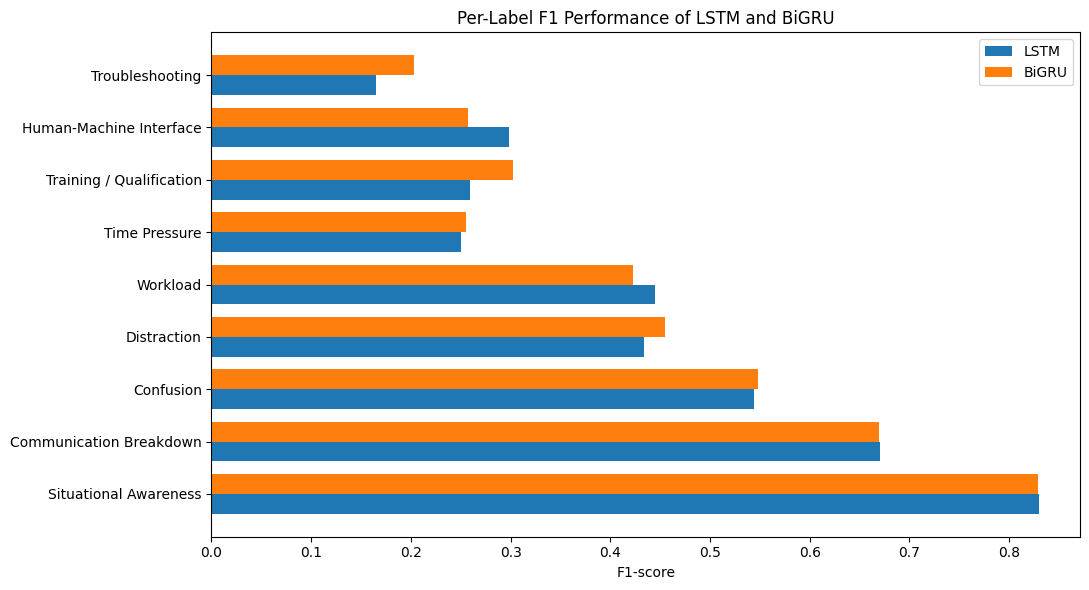

In [49]:
per_label_comparison = (
    lstm_label_results[
        ['Human factor', 'F1-score']
    ]
    .rename(
        columns={'F1-score': 'LSTM F1'}
    )
    .merge(
        bigru_label_results[
            ['Human factor', 'F1-score']
        ].rename(
            columns={'F1-score': 'BiGRU F1'}
        ),
        on='Human factor'
    )
)

plot_positions = np.arange(
    len(per_label_comparison)
)

bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_positions - bar_width / 2,
    per_label_comparison['LSTM F1'],
    height=bar_width,
    label='LSTM'
)

ax.barh(
    plot_positions + bar_width / 2,
    per_label_comparison['BiGRU F1'],
    height=bar_width,
    label='BiGRU'
)

ax.set_yticks(
    plot_positions,
    per_label_comparison['Human factor']
)

ax.set_xlabel('F1-score')
ax.set_title('Per-Label F1 Performance of LSTM and BiGRU')
ax.legend()

plt.tight_layout()

plt.savefig(
    figures_folder / 'lstm_bigru_per_label_f1.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

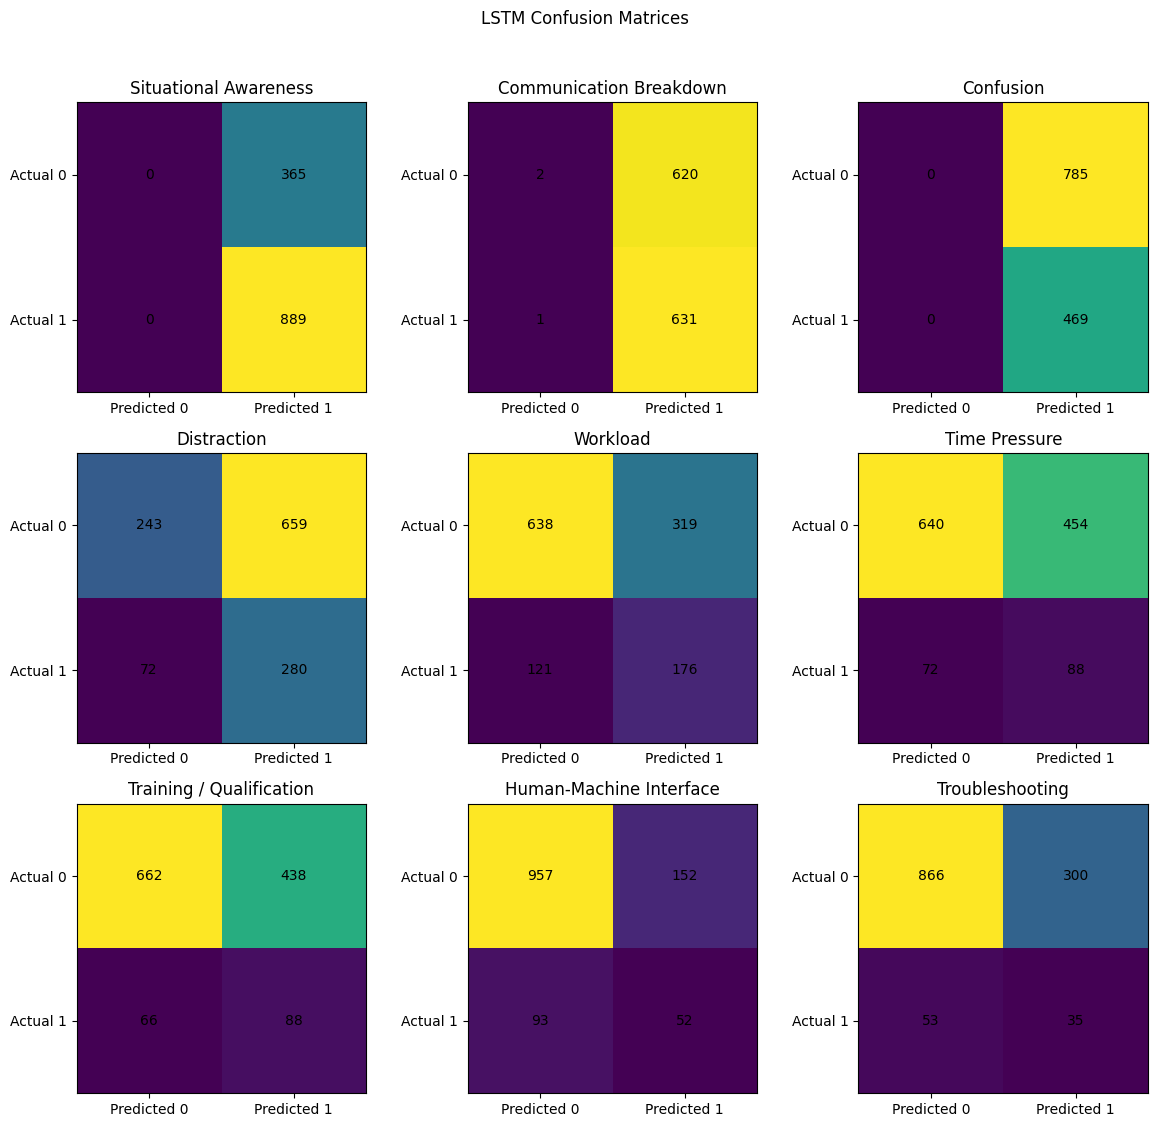

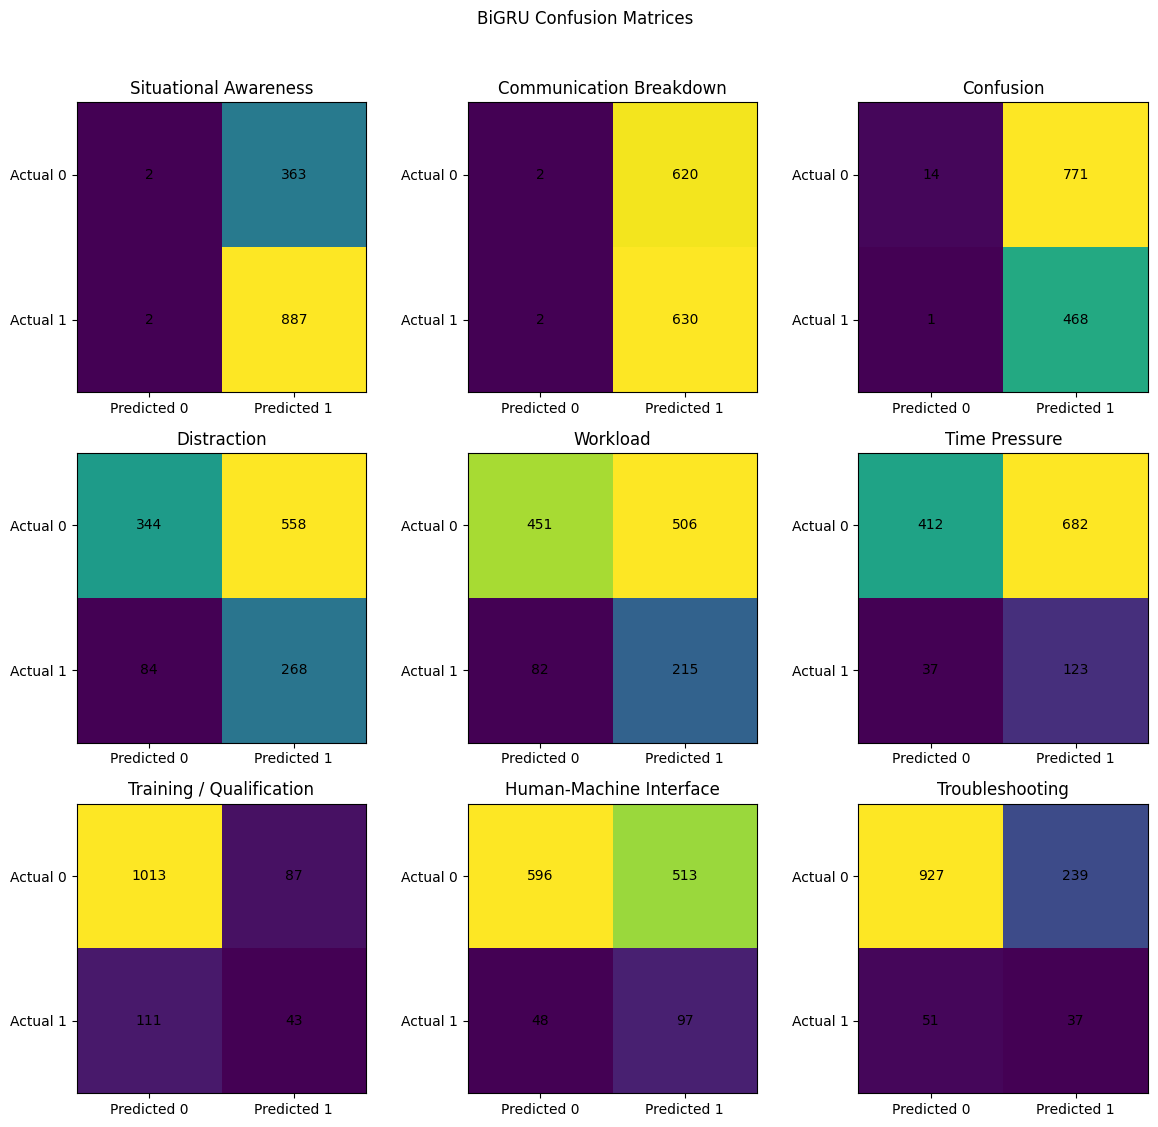

In [50]:
from sklearn.metrics import multilabel_confusion_matrix

def plot_multilabel_confusion_matrices(
    true_labels,
    predicted_labels,
    label_names,
    model_name,
    file_name
):
    confusion_matrices = multilabel_confusion_matrix(
        true_labels,
        predicted_labels
    )

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(12, 11)
    )

    axes = axes.flatten()

    for index, label in enumerate(label_names):
        matrix = confusion_matrices[index]

        axes[index].imshow(matrix)

        axes[index].set_title(label)

        axes[index].set_xticks(
            [0, 1],
            ['Predicted 0', 'Predicted 1']
        )

        axes[index].set_yticks(
            [0, 1],
            ['Actual 0', 'Actual 1']
        )

        for row in range(2):
            for column in range(2):
                axes[index].text(
                    column,
                    row,
                    matrix[row, column],
                    ha='center',
                    va='center'
                )

    fig.suptitle(
        f'{model_name} Confusion Matrices',
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        figures_folder / file_name,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


plot_multilabel_confusion_matrices(
    y_test,
    lstm_test_predictions,
    human_factor_labels,
    'LSTM',
    'lstm_confusion_matrices.png'
)

plot_multilabel_confusion_matrices(
    y_test,
    bigru_test_predictions,
    human_factor_labels,
    'BiGRU',
    'bigru_confusion_matrices.png'
)

## 14. Error Analysis

Aggregate metrics do not show why individual reports are misclassified. The test predictions are therefore examined at report level by counting false-positive and false-negative labels. This allows difficult or unusual narratives to be identified for later qualitative discussion.

In [51]:
# Choose the stronger sequence model using validation Macro-F1.
# Model selection is based only on validation performance,
# not on the test-set results.

lstm_validation_predictions = (
    lstm_validation_probabilities
    >= lstm_thresholds
).astype(int)

bigru_validation_predictions = (
    bigru_validation_probabilities
    >= bigru_thresholds
).astype(int)


lstm_validation_macro_f1 = f1_score(
    y_validation,
    lstm_validation_predictions,
    average='macro',
    zero_division=0
)

bigru_validation_macro_f1 = f1_score(
    y_validation,
    bigru_validation_predictions,
    average='macro',
    zero_division=0
)


print(
    f"LSTM validation Macro-F1: "
    f"{lstm_validation_macro_f1:.4f}"
)

print(
    f"BiGRU validation Macro-F1: "
    f"{bigru_validation_macro_f1:.4f}"
)


if bigru_validation_macro_f1 > lstm_validation_macro_f1:

    selected_sequence_model_name = 'BiGRU'

    selected_sequence_model = bigru_model

    selected_test_probabilities = (
        bigru_test_probabilities
    )

    selected_test_predictions = (
        bigru_test_predictions
    )

    selected_sequence_thresholds = (
        bigru_thresholds
    )

else:

    selected_sequence_model_name = 'LSTM'

    selected_sequence_model = lstm_model

    selected_test_probabilities = (
        lstm_test_probabilities
    )

    selected_test_predictions = (
        lstm_test_predictions
    )

    selected_sequence_thresholds = (
        lstm_thresholds
    )


# Count false-positive and false-negative labels
# for each test report.

false_positive_counts = (
    (
        (selected_test_predictions == 1)
        & (y_test == 0)
    )
    .sum(axis=1)
)

false_negative_counts = (
    (
        (selected_test_predictions == 0)
        & (y_test == 1)
    )
    .sum(axis=1)
)


test_error_analysis = pd.DataFrame({
    'ACN': report_acns[test_indices],
    'Narrative': X_test,
    'False positives': false_positive_counts,
    'False negatives': false_negative_counts
})


test_error_analysis[
    'Total label errors'
] = (
    test_error_analysis['False positives']
    + test_error_analysis['False negatives']
)


test_error_analysis.sort_values(
    'Total label errors',
    ascending=False,
    inplace=True
)


display(
    test_error_analysis.head(10)
)


test_error_analysis.to_csv(
    tables_folder / 'test_error_analysis.csv',
    index=False
)


print(
    f"Model selected for detailed analysis: "
    f"{selected_sequence_model_name}"
)

LSTM validation Macro-F1: 0.4469
BiGRU validation Macro-F1: 0.4527


,ACN,Narrative,False positives,False negatives,Total label errors
475,1221260,Well I am not sure how to fill out this report...,8,1,9
1218,2207767,Aircraft X was inbound for 46U at 160 when the...,8,1,9
615,1345158,Aircraft X was in level flight. There was weat...,7,1,8
698,1404391,The weather was zero visibility in the Tower w...,7,1,8
557,1300604,Aircraft X started takeoff roll before Aircraf...,7,1,8
147,946048,A massive thunderstorm system of historic prop...,7,1,8
1033,1774741,I was on Local Control. Ground Control was com...,8,0,8
762,1451607,I was working Local Control. Aircraft X depart...,7,1,8
1213,2172995,Sector XX with no notice or training was assig...,8,0,8
881,1578346,OAPM [Optimization of Airspace and Procedures ...,8,0,8


Model selected for detailed analysis: BiGRU


## 15. Explainability Analysis

SHAP is applied to the stronger sequence model to examine how individual words influence a selected human-factor prediction. The explanation is interpreted as evidence about model behaviour rather than as a causal explanation of the underlying aviation event.

In [52]:
%pip install -q shap

import shap

In [53]:
test_word_counts = np.array([
    len(text.split())
    for text in X_test
])


# Identifies human-factor labels that the selected model
# predicted correctly as present in each report.
true_positive_predictions = (
    (selected_test_predictions == 1)
    & (y_test == 1)
)


# Restrict the explanation to moderately sized narratives
# that contain at least one correctly predicted positive label.
candidate_examples = np.where(
    (
        (test_word_counts >= 80)
        & (test_word_counts <= 250)
    )
    & true_positive_predictions.any(axis=1)
)[0]


if len(candidate_examples) == 0:
    raise ValueError(
        "No suitable correctly classified report was found "
        "for the SHAP explanation."
    )


# Consider probabilities only for labels that were
# correctly predicted as positive.
candidate_true_positive_mask = (
    true_positive_predictions[
        candidate_examples
    ]
)

candidate_probabilities = (
    selected_test_probabilities[
        candidate_examples
    ]
)

eligible_probabilities = np.where(
    candidate_true_positive_mask,
    candidate_probabilities,
    -np.inf
)


# Select the highest-confidence correctly predicted
# positive human-factor label.
best_prediction_position = np.argmax(
    eligible_probabilities
)

candidate_position, focus_label_index = (
    np.unravel_index(
        best_prediction_position,
        eligible_probabilities.shape
    )
)


explanation_example_index = (
    candidate_examples[
        candidate_position
    ]
)

focus_label_name = (
    human_factor_labels[
        focus_label_index
    ]
)


print(
    f"Report selected for explanation: "
    f"{report_acns[test_indices][explanation_example_index]}"
)

print(
    f"Human-factor output being explained: "
    f"{focus_label_name}"
)

print(
    f"Predicted probability: "
    f"{selected_test_probabilities[explanation_example_index, focus_label_index]:.3f}"
)

print(
    f"Decision threshold: "
    f"{selected_sequence_thresholds[focus_label_index]:.2f}"
)

print(
    "Prediction status: Correct positive prediction"
)

Report selected for explanation: 2312357
Human-factor output being explained: Training / Qualification
Predicted probability: 0.990
Decision threshold: 0.76
Prediction status: Correct positive prediction


In [54]:
def predict_human_factor_probabilities(text_samples):
    """Returns human-factor probabilities for raw narrative strings."""

    text_samples = np.asarray(
        text_samples,
        dtype=str
    )

    vectorised_samples = (
        text_vectorizer(
            tf.constant(text_samples)
        )
        .numpy()
    )

    return selected_sequence_model.predict(
        vectorised_samples,
        verbose=0
    )


def predict_focus_human_factor(text_samples):
    """Returns probabilities only for the human-factor label being explained."""

    all_probabilities = (
        predict_human_factor_probabilities(
            text_samples
        )
    )

    return all_probabilities[
        :,
        focus_label_index
    ]


# Uses a word-based placeholder when SHAP masks parts of the narrative.
# This avoids creating zero-padding inside the sequence.
text_masker = shap.maskers.Text(
    mask_token='shapmaskedword',
    collapse_mask_token=False
)

text_explainer = shap.Explainer(
    predict_focus_human_factor,
    text_masker,
    algorithm='partition'
)

shap_explanation = text_explainer(
    [
        X_test[
            explanation_example_index
        ]
    ],
    max_evals=500
)

shap.plots.text(
    shap_explanation[0]
)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:28, 28.09s/it]               


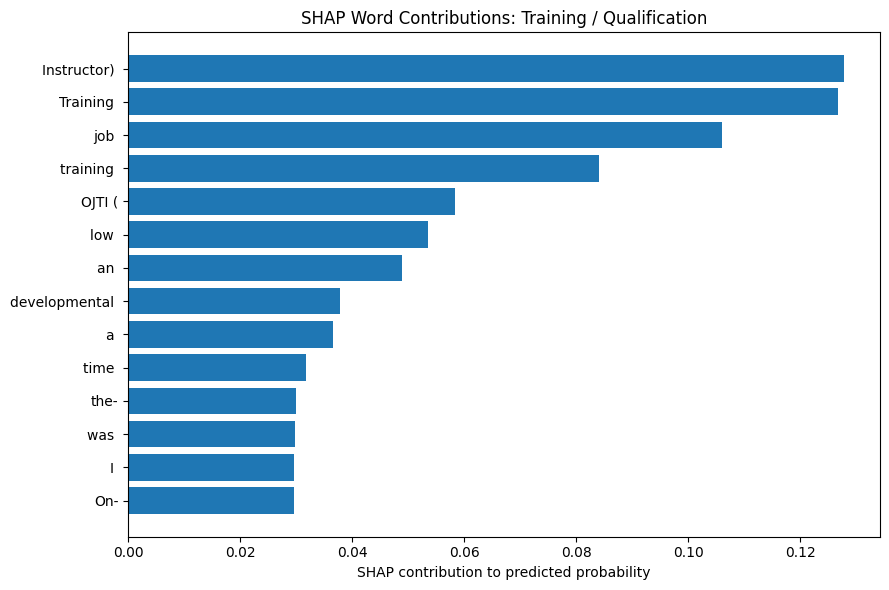

In [55]:
token_names = np.asarray(
    shap_explanation.data[0]
)

token_contributions = np.asarray(
    shap_explanation.values[0]
)

most_influential_tokens = np.argsort(
    np.abs(token_contributions)
)[-15:]

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    token_names[most_influential_tokens],
    token_contributions[most_influential_tokens]
)

ax.set_title(
    f'SHAP Word Contributions: {focus_label_name}'
)

ax.set_xlabel(
    'SHAP contribution to predicted probability'
)

plt.tight_layout()

plt.savefig(
    figures_folder / 'shap_local_word_contributions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 16. Saving Experiment Outputs

The final models, performance tables, label-level results and experiment settings are saved to Google Drive.

In [56]:
lstm_label_results.to_csv(
    tables_folder / 'lstm_per_label_results.csv',
    index=False
)

bigru_label_results.to_csv(
    tables_folder / 'bigru_per_label_results.csv',
    index=False
)

baseline_threshold_table.to_csv(
    tables_folder / 'baseline_threshold_search.csv',
    index=False
)

lstm_threshold_table.to_csv(
    tables_folder / 'lstm_threshold_search.csv',
    index=False
)

bigru_threshold_table.to_csv(
    tables_folder / 'bigru_threshold_search.csv',
    index=False
)

joblib.dump(
    tfidf_vectorizer,
    models_folder / 'tfidf_vectorizer.joblib'
)

joblib.dump(
    baseline_classifier,
    models_folder / 'baseline_logistic_regression.joblib'
)

# Saves the vocabulary used by both recurrent models.
with open(
    outputs_folder / 'text_vocabulary.txt',
    'w',
    encoding='utf-8'
) as vocabulary_file:

    for word in vocabulary:
        vocabulary_file.write(
            word + '\n'
        )


def format_thresholds_for_settings(
    label_names,
    thresholds
):
    """Creates a readable summary of per-label decision thresholds."""

    return ' | '.join(
        [
            f'{label_name}: {threshold:.2f}'
            for label_name, threshold
            in zip(
                label_names,
                thresholds
            )
        ]
    )


experiment_settings = pd.DataFrame({
    'Setting': [
        'Random seed',
        'Minimum reports per label',
        'Number of labels',
        'Maximum vocabulary size',
        'Actual vocabulary size',
        'Sequence length',
        'Embedding dimension',
        'Training reports',
        'Validation reports',
        'Test reports',
        'Threshold selection method',
        'Baseline per-label thresholds',
        'LSTM per-label thresholds',
        'BiGRU per-label thresholds',
        'Selected sequence model'
    ],

    'Value': [
        random_seed,
        minimum_reports_per_label,
        number_of_labels,
        maximum_vocabulary_size,
        len(vocabulary),
        sequence_length,
        embedding_dimension,
        len(X_train),
        len(X_validation),
        len(X_test),

        'Per-label F1 optimisation on validation data',

        format_thresholds_for_settings(
            human_factor_labels,
            baseline_thresholds
        ),

        format_thresholds_for_settings(
            human_factor_labels,
            lstm_thresholds
        ),

        format_thresholds_for_settings(
            human_factor_labels,
            bigru_thresholds
        ),

        selected_sequence_model_name
    ]
})


experiment_settings.to_csv(
    outputs_folder / 'experiment_settings.csv',
    index=False
)


display(
    experiment_settings
)


print(
    "\nAll main outputs have been saved."
)

,Setting,Value
0,Random seed,2026
1,Minimum reports per label,200
2,Number of labels,9
3,Maximum vocabulary size,12000
4,Actual vocabulary size,12000
5,Sequence length,700
6,Embedding dimension,64
7,Training reports,5929
8,Validation reports,1254
9,Test reports,1254



All main outputs have been saved.
